In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons, make_circles

from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture
import matplotlib.patches as patches
from numpy.linalg import eigh
from sklearn.metrics import silhouette_score

## 1. Dataset generation

In [2]:
# Gaussian dataset (blobs)

X_blobs, y_blobs = make_blobs(
    n_samples=500,
    centers=3,
    cluster_std=1.0,
    random_state=42
)

In [3]:
# Non linear dataset (moons)

X_moons, y_moons = make_moons(
    n_samples=500,
    noise=0.05,
    random_state=42
)

In [4]:
# Nested dataset (circles)

X_circles, y_circles = make_circles(
    n_samples=500,
    factor=0.5,
    noise=0.05,
    random_state=42
)

In [5]:
# Customed dataset

def generate_custom_dataset(n_samples=500, random_state=42):

    # Dense cluster
    cluster1 = np.random.normal(loc=[0,0], scale=0.3, size=(int(n_samples*0.4),2))

    # Sparse cluster 
    cluster2 = np.random.normal(loc=[3,3], scale=1.0, size=(int(n_samples*0.4),2))

    # Noise
    noise = np.random.uniform(low=-4, high=6, size=(int(n_samples*0.2),2))

    X = np.vstack([cluster1, cluster2, noise])
    return X

In [6]:
X_custom = generate_custom_dataset()

In [7]:
# Function to plot

def plot_dataset(X, title):

    plt.figure(figsize=(5,5))
    plt.scatter(X[:,0], X[:,1], s=10)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)
    plt.show()

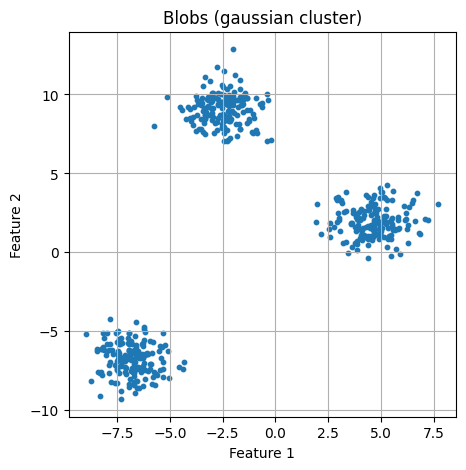

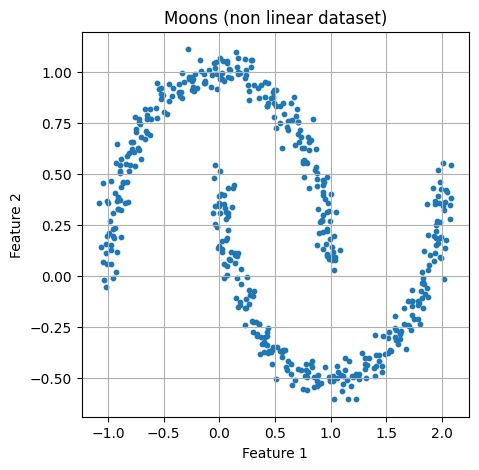

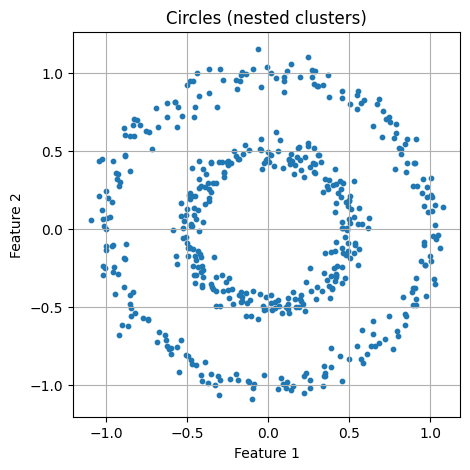

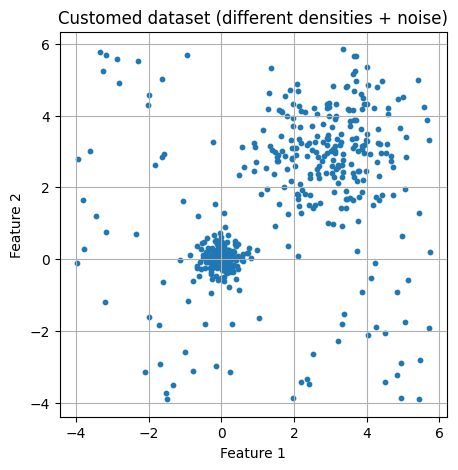

In [8]:
plot_dataset(X_blobs, "Blobs (gaussian cluster)")
plot_dataset(X_moons, "Moons (non linear dataset)")
plot_dataset(X_circles, "Circles (nested clusters)")
plot_dataset(X_custom, "Customed dataset (different densities + noise)")

I generated different datasets under different assumptions:
* Blobs are well separated gaussian clusters (ideal for GMM)
* Moons and circles are non linear datasets (challenging for GMM)
* Customed dataset, with varying densities and noise (ideal to test DBSCAN robustness)

## 2. DBSCAN

I recall that:
* Core points are those with many neighbors within epsilon
* Border points are close to core points but less dense
* Noise points are isolated

In [9]:
# Function to run DBSCAN

def run_dbscan(X, eps=0.3, min_samples=5):
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(X)
    return model, labels

In [10]:
# Function to plot

def plot_dbscan(X, labels, model, title):
    unique_labels = set(labels)
    plt.figure(figsize=(6,6))

    for label in unique_labels:
        if label == -1:
            color = "black" # Noise
            label_name = "Noise"
        else:
            color = plt.cm.tab10(label)
            label_name = f"Cluster {label}"

        class_mask = (labels == label)

        # Core points
        core_mask = np.zeros_like(labels, dtype=bool)
        core_mask[model.core_sample_indices_] = True

        plt.scatter(
            X[class_mask & core_mask, 0],
            X[class_mask & core_mask, 1],
            c = [color],
            s = 50,
            label = label_name,
            edgecolors = "k"
        )

        # Border points
        plt.scatter(
            X[class_mask & ~core_mask, 0],
            X[class_mask & ~core_mask, 1],
            c = [color],
            s = 20
        )

    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

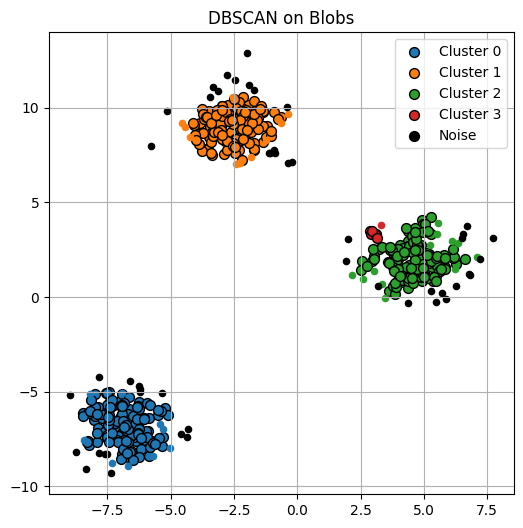

In [11]:
# Blobs

model_blobs, labels_blobs = run_dbscan(X_blobs, eps=0.5, min_samples=5)
plot_dbscan(X_blobs, labels_blobs, model_blobs, "DBSCAN on Blobs")

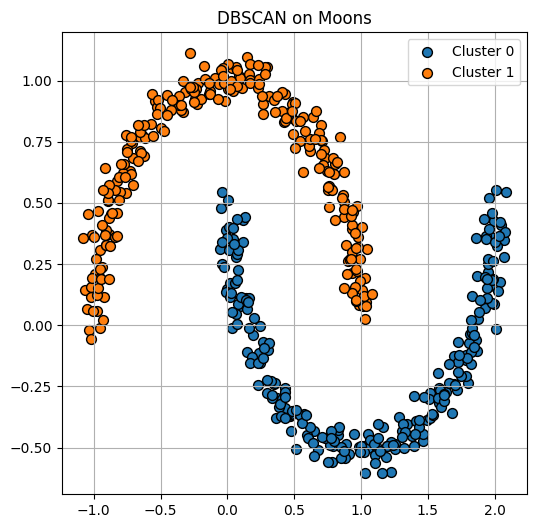

In [12]:
# Moons

model_moons, labels_moons = run_dbscan(X_moons, eps=0.2, min_samples=5)
plot_dbscan(X_moons, labels_moons, model_moons, "DBSCAN on Moons")

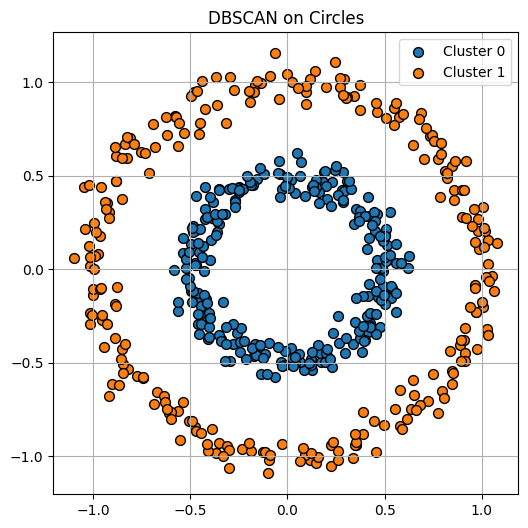

In [13]:
# Circles

model_circles, labels_circles = run_dbscan(X_circles, eps=0.2, min_samples=5)
plot_dbscan(X_circles, labels_circles, model_circles, "DBSCAN on Circles")

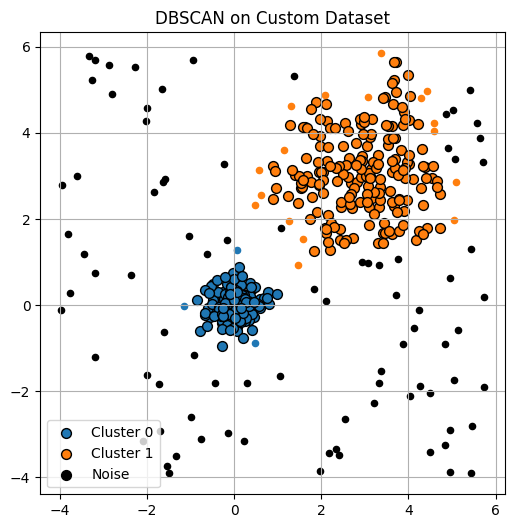

In [14]:
# Custom dataset

model_custom, labels_custom = run_dbscan(X_custom, eps=0.5, min_samples=5)
plot_dbscan(X_custom, labels_custom, model_custom, "DBSCAN on Custom Dataset")

In general, DBSCAN performs quite well. 
* Clusters are perfectly defined in the moons and circles datasets
* In blobs dataset, it also performs well, even if it identifies one small extra cluster
* In the customed dataset, it classifies well points into the two clusters with different densities and most of outliers. However, it identifies other 4 small extra clusters

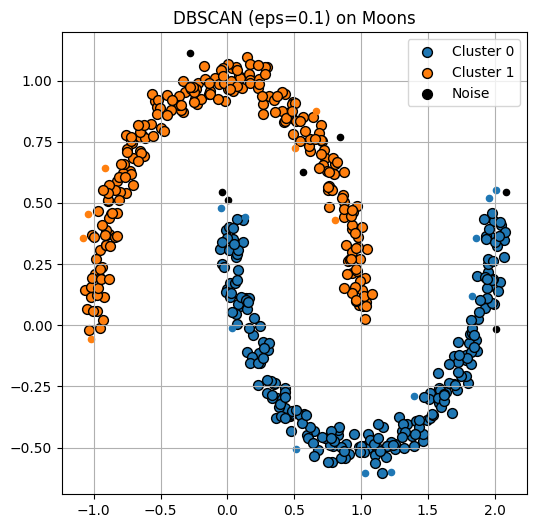

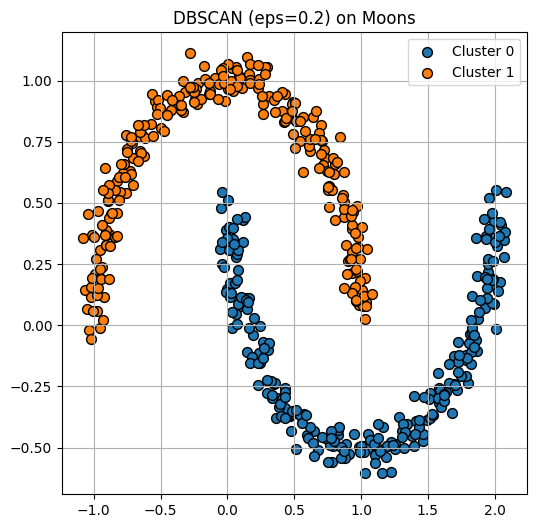

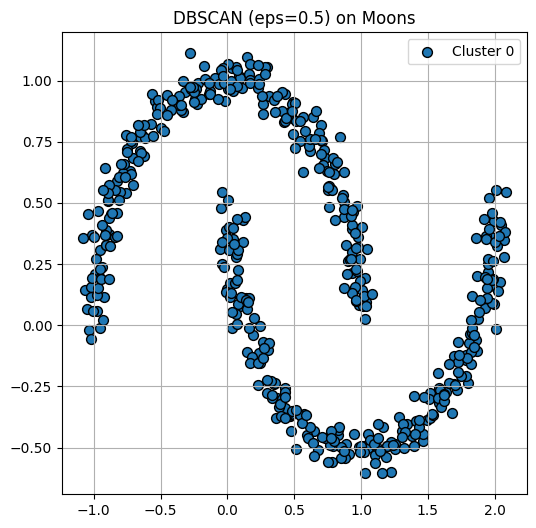

In [15]:
# Effect of epsilon

eps_values = [0.1, 0.2, 0.5]

for eps in eps_values:
    model, labels = run_dbscan(X_moons, eps=eps)
    plot_dbscan(X_moons, labels, model, f"DBSCAN (eps={eps}) on Moons")

* For small eps, some data points are misclassified as noise
* For larg eps, clusters merge

## 3. GMM

In [16]:
# Function to run GMM

def run_gmm(X, n_components=2, covariance_type="full"):
    model = GaussianMixture(
        n_components=n_components,
        covariance_type=covariance_type,
        random_state=42
    )
    labels = model.fit_predict(X)
    probs = model.predict_proba(X)
    return model, labels, probs

In [17]:
# Fuction for visualization

def draw_ellipse(position, covariance, ax, **kwargs):

    if covariance.shape == (2,2):
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2*np.sqrt(s)

    else:
        angle = 0
        width, height = 2*np.sqrt(covariance)

    for nsig in range(1,4):
        ax.add_patch(
            patches.Ellipse(position, nsig*width, nsig*height, angle=angle, fill=False, **kwargs)
        )

In [18]:
def plot_gmm_ellipses(X, model, labels, title):
    fig, ax = plt.subplots(figsize=(6,6))

    ax.scatter(X[:,0], X[:,1], c=labels, s=20, cmap="viridis")

    for i in range(model.n_components):
        draw_ellipse(
            model.means_[i],
            model.covariances_[i],
            ax,
            edgecolor="red"
        )

    ax.set_title(title)
    ax.grid(True)
    plt.show()

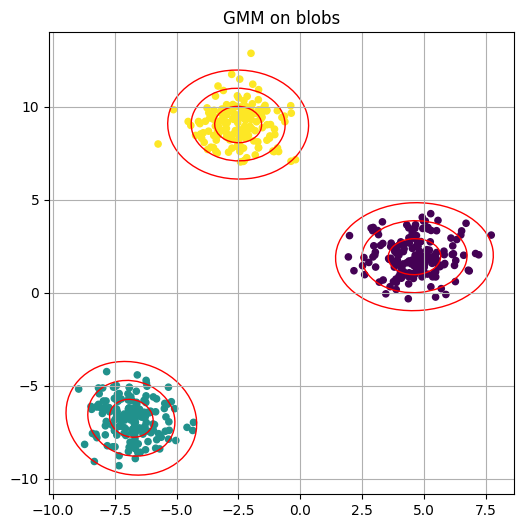

In [19]:
# Blobs

model_blobs_gmm, labels_blobs_gmm, probs_blobs = run_gmm(X_blobs, n_components=3)
plot_gmm_ellipses(X_blobs, model_blobs_gmm, labels_blobs_gmm, "GMM on blobs")

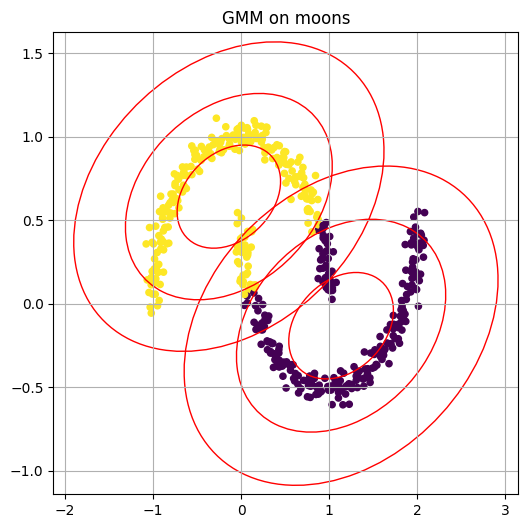

In [20]:
# Moons

model_moons_gmm, labels_moons_gmm, probs_moons = run_gmm(X_moons, n_components=2)
plot_gmm_ellipses(X_moons, model_moons_gmm, labels_moons_gmm, "GMM on moons")

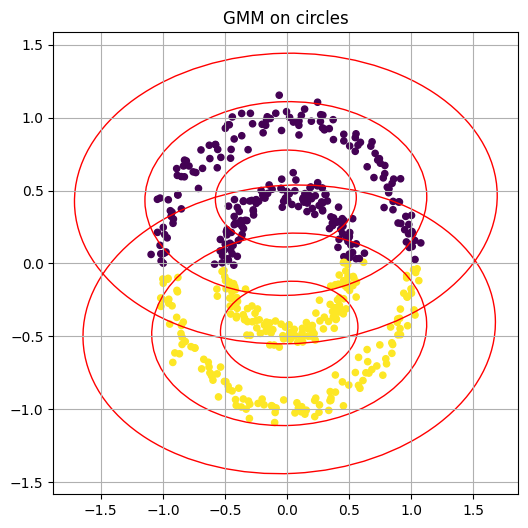

In [21]:
# Circles

model_circles_gmm, labels_circles_gmm, probs_circles = run_gmm(X_circles, n_components=2)
plot_gmm_ellipses(X_circles, model_circles_gmm, labels_circles_gmm, "GMM on circles")

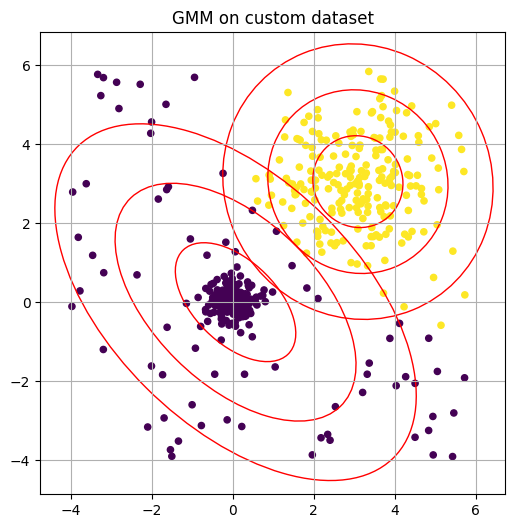

In [22]:
# Custom dataset

model_custom_gmm, labels_custom_gmm, probs_custom = run_gmm(X_custom, n_components=2)
plot_gmm_ellipses(X_custom, model_custom_gmm, labels_custom_gmm, "GMM on custom dataset")

* GMM works well with blobs dataset (gaussian shaped dataset)
* It struggles with non-linear datasets, as circles and moons
* It also performes quite well with the customed dataset, even if it cannot find outliers

In [23]:
# Show probabilities

def plot_gmm_probabilities(X, probs, title):
    confidence = probs.max(axis=1)

    plt.figure(figsize=(6,6))
    plt.scatter(X[:,0], X[:,1], c=confidence, s=20, cmap="viridis")
    plt.colorbar(label="Confidence")
    plt.title(title)
    plt.grid(True)
    plt.show()

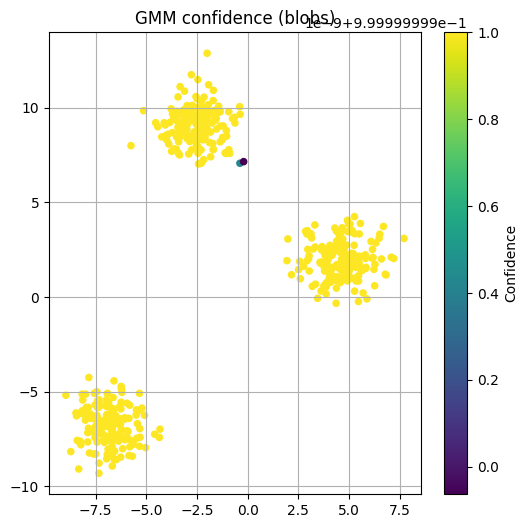

In [24]:
plot_gmm_probabilities(X_blobs, probs_blobs, "GMM confidence (blobs)")

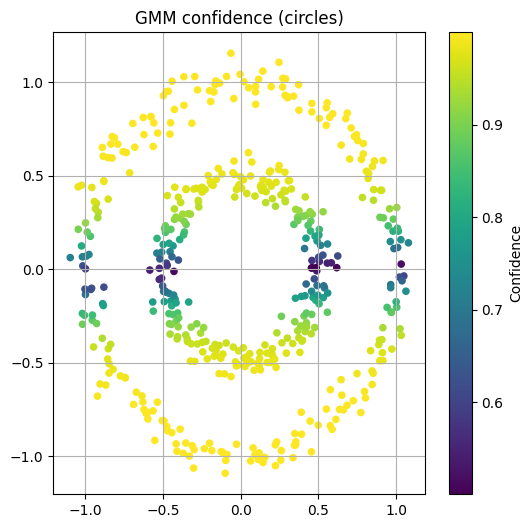

In [25]:
plot_gmm_probabilities(X_circles, probs_circles, "GMM confidence (circles)")

I see how GMM is usually veru confident in classifying points in the blobs dataset. In the circles dataset instead it struggles in classifying many more points, falling at the intersection between the two clusters.

In [26]:
# Model selection with BIC

def gmm_bic_analysis(X, max_k=6):
    bics = []
    ks = range(1, max_k+1)

    for k in ks:
        gmm = GaussianMixture(n_components=k, random_state=42)
        gmm.fit(X)
        bics.append(gmm.bic(X))

    plt.plot(ks, bics, marker='o')
    plt.xlabel("Number of components")
    plt.ylabel("BIC")
    plt.title("GMM model selection (BIC)")
    plt.grid(True)
    plt.show()

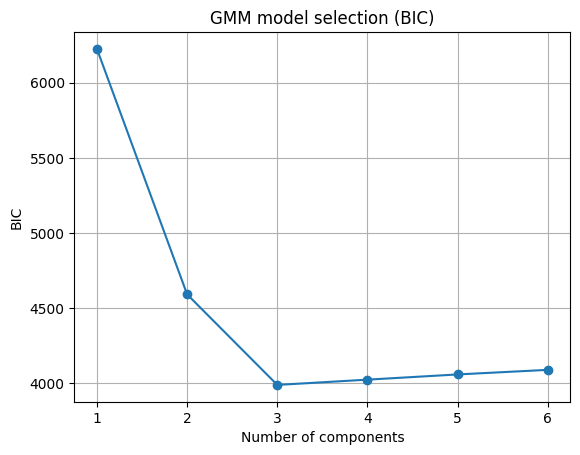

In [27]:
gmm_bic_analysis(X_blobs)

As expected, for this dataset (blobs), 3 is the number of clusters to choose.

## 4. Comparison

In [28]:
# Function to compare algorithms

def compare_clustering(X, dbscan_labels, gmm_labels, title):
    fig, axes = plt.subplots(1, 2, figsize=(12,5))

    # DBSCAN
    axes[0].scatter(X[:,0], X[:,1], c=dbscan_labels, s=20, cmap="tab10")
    axes[0].set_title("DBSCAN")
    axes[0].grid(True)

    # GMM
    axes[1].scatter(X[:,0], X[:,1], c=gmm_labels, s=20, cmap="viridis")
    axes[1].set_title("GMM")
    axes[1].grid(True)

    fig.suptitle(title)
    plt.show()

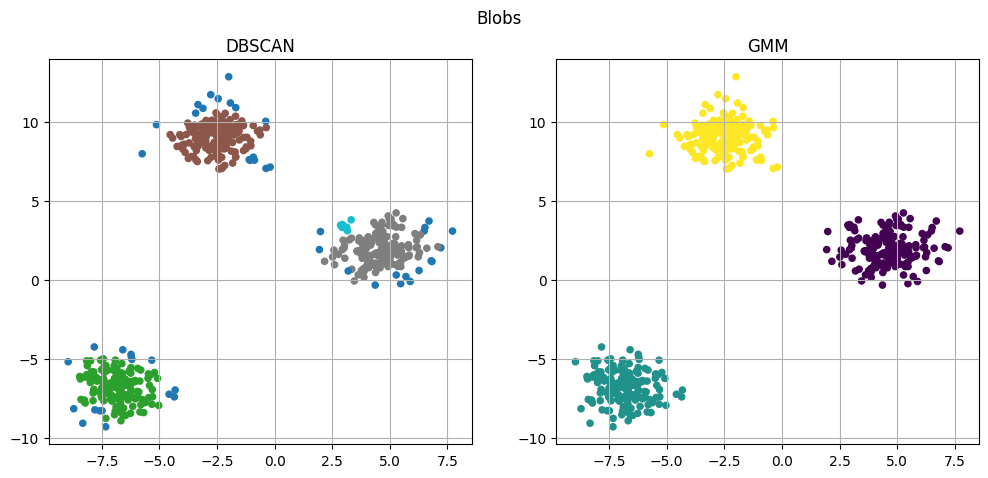

In [29]:
# Blobs

compare_clustering(X_blobs, labels_blobs, labels_blobs_gmm, "Blobs")

They both perform well, but GMM is more precise.

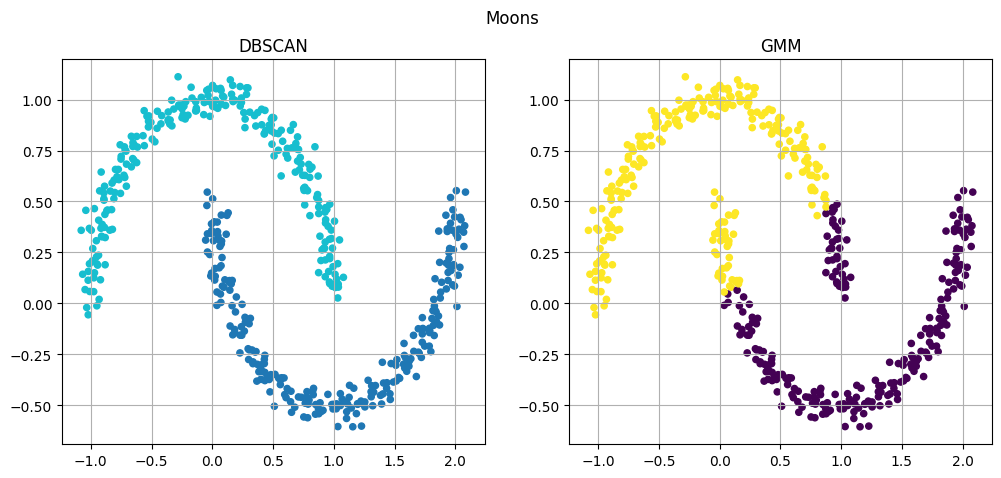

In [30]:
# Moons

compare_clustering(X_moons, labels_moons, labels_moons_gmm, "Moons")

DBSCAN works well, while GMM "cuts" in the wrong way.

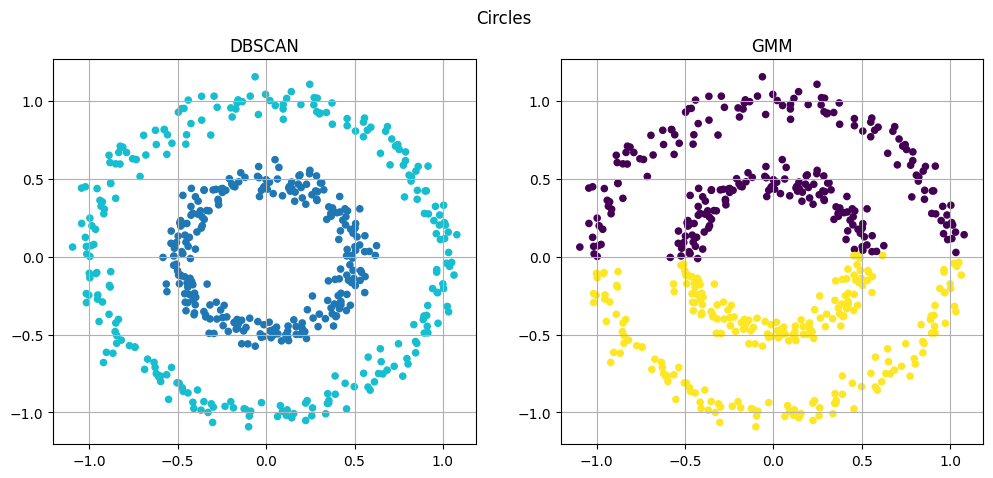

In [31]:
# Circles

compare_clustering(X_circles, labels_circles, labels_circles_gmm, "Circles")

Also here, DBSCAN performs well and GMM doesn't.

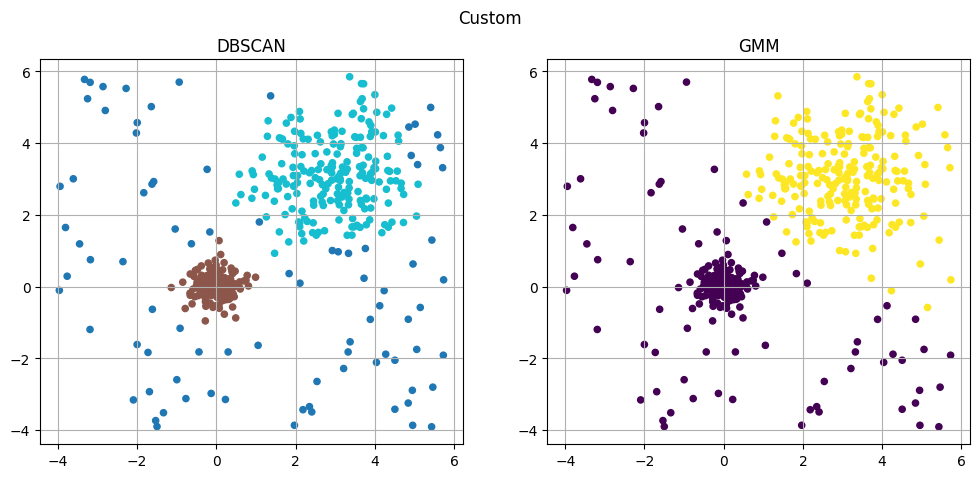

In [32]:
# Customed dataset

compare_clustering(X_custom, labels_custom, labels_custom_gmm, "Custom")

DBSCAN is able to handle noise, while GMM is not able.

In [34]:
# Metrics -> Silhouette score

def compute_silhouette(X, labels):
    if len(set(labels)) <= 1 or len(set(labels)) == len(X):
        return None
    return silhouette_score(X, labels)

In [36]:
# Blobs
print("\nBlobs")
print(f"DBSCAN: {compute_silhouette(X_blobs, labels_blobs)}")
print(f"GMM: {compute_silhouette(X_blobs, labels_blobs_gmm)}")

# Moons
print("\nMoons")
print(f"DBSCAN: {compute_silhouette(X_moons, labels_moons)}")
print(f"GMM: {compute_silhouette(X_moons, labels_moons_gmm)}")

# Circles
print("\nCircles")
print(f"DBSCAN: {compute_silhouette(X_circles, labels_circles)}")
print(f"GMM: {compute_silhouette(X_circles, labels_circles_gmm)}")

# Custom
print("\nCustom")
print(f"DBSCAN: {compute_silhouette(X_custom, labels_custom)}")
print(f"GMM: {compute_silhouette(X_custom, labels_custom_gmm)}")


Blobs
DBSCAN: 0.5240093460562923
GMM: 0.8437565906781406

Moons
DBSCAN: 0.3340617528457047
GMM: 0.4739661696620789

Circles
DBSCAN: 0.11259270668373579
GMM: 0.34838968107874085

Custom
DBSCAN: 0.536676389666284
GMM: 0.5785574376317976


In [37]:
import pandas as pd

results = pd.DataFrame({
    "Dataset": ["Blobs", "Moons", "Circles", "Custom"],
    "DBSCAN Silhouette": [
        compute_silhouette(X_blobs, labels_blobs),
        compute_silhouette(X_moons, labels_moons),
        compute_silhouette(X_circles, labels_circles),
        compute_silhouette(X_custom, labels_custom)
    ],
    "GMM Silhouette": [
        compute_silhouette(X_blobs, labels_blobs_gmm),
        compute_silhouette(X_moons, labels_moons_gmm),
        compute_silhouette(X_circles, labels_circles_gmm),
        compute_silhouette(X_custom, labels_custom_gmm)
    ]
})

results

,Dataset,DBSCAN Silhouette,GMM Silhouette
0,Blobs,0.524009,0.843757
1,Moons,0.334062,0.473966
2,Circles,0.112593,0.348390
3,Custom,0.536676,0.578557


* Blobs $\rightarrow$ clusters are gaussian, so the results are in accordance with the model assumption
* Moons and Circles $\rightarrow$ Silhouette score favours convex clusters, so it penalizes DBSCAN even if it performs better
* Custom $\rightarrow$ GMM appears better numerically, but it actually fails in modeling noise

Silhouette score alone is not sufficient for evaluating clustering quality. Visual inspection is crucial in this case.